In [54]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from torch.utils.data import Dataset,DataLoader
import pandas as pd 
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import numpy as np
from torchvision import models, transforms
from torchmetrics.image.fid import FrechetInceptionDistance
import lpips as lpips_lib
import random


In [ ]:
#dataclass for dependency injection



class TrainDataset(Dataset):
    def __init__(self,dir_path,csv_path,transformation=None,augment=False):
        self.prefix = "face-"
        self.dir = dir_path
        self.df = pd.read_csv(csv_path)
        self.transform = transformation
        self.augment = augment

        transforms = []
        if self.augment:
            transforms += [

                A.Affine(
                translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                scale=(0.95, 1.05),
                rotate=(-10, 10),
                border_mode=cv2.BORDER_REFLECT_101,
                p=0.6
                ),
                A.HorizontalFlip(p=0.5),
 
             
                A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.3
            ),

                A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
            ]
 
        transforms += [
            A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0],
                        max_pixel_value=255.0),
            ToTensorV2()
        ]
        self.transforms = A.Compose(transforms)
 
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        label = int(self.df.iloc[index]["glasses"])
        img_name = self.prefix + f"{index + 1}.png"
        img_path = os.path.join(self.dir, img_name)

        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

       
        img = self.transforms(image=img)["image"]

        return img,label
    

#dataloader


dataset = TrainDataset(
    dir_path="resized_dataset",
    csv_path="train-corrected.csv",
    augment=True
)

loader = DataLoader(dataset, batch_size=64, shuffle=True,pin_memory=True)

def visualize_augments(loader,n=16):
   
    imgs,labels = next(iter(loader))

    imgs         = imgs[:n].permute(0, 2, 3, 1).numpy()
    labels       = labels[:n].numpy()

    label_names={
        1:"glasses",
        0:"no-glasses"
    }
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(imgs[i], 0, 1))
        ax.set_title(label_names[labels[i]], fontsize=8)
        ax.axis("off")
    plt.suptitle("augments visualized")
    plt.tight_layout()
    plt.show()

    



In [57]:




def get_activation(name: str) -> nn.Module:
    _map = {
        "relu":      nn.ReLU(),
        "leakyrelu": nn.LeakyReLU(negative_slope=0.2),
        "elu":       nn.ELU(),
    }
    key = name.lower().replace("-", "").replace("_", "")
    return _map[key]



class VAE(nn.Module):
    def __init__(self, z_dim: int = 64, activation: str = "leakyrelu"):
        super().__init__()
        self.z_dim      = z_dim
        self.activation = activation          
        self.label_emb  = nn.Embedding(2, 16)

       
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),      
            get_activation(activation),
            nn.Conv2d(32, 64, 4, 2, 1),      
            get_activation(activation),
            nn.Conv2d(64, 128, 4, 2, 1),      
            get_activation(activation),
        )

        
        self.fc_mu     = nn.Linear(128 * 8 * 8 + 16, z_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8 + 16, z_dim)

     
        self.fc_dec = nn.Linear(z_dim + 16, 128 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   
            get_activation(activation),
            nn.Dropout(0.2),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  
            get_activation(activation),
            nn.Dropout(0.2),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     
            nn.Sigmoid(),                            
        )

    def encode(self, x, y):
        h     = self.encoder(x).view(x.size(0), -1)
        y_emb = self.label_emb(y)
        h     = torch.cat([h, y_emb], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        h     = self.fc_dec(torch.cat([z, y_emb], dim=1))
        return self.decoder(h.view(-1, 128, 8, 8))

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar



def vae_loss(recon, x, mu, logvar, beta: float, loss_type: str = "MSE"):
    lt = loss_type.upper()
    if lt == "MSE":
        recon_loss = F.mse_loss(recon, x, reduction="mean")
    elif lt == "L1":
        recon_loss = F.l1_loss(recon, x, reduction="mean")
    
    kl         = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total      = recon_loss + beta * kl
    return total, recon_loss.item(), kl.item()




In [58]:

eval_dataset = TrainDataset(
    dir_path="resized_dataset",
    csv_path="train-corrected.csv",
    augment=False
)
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False, pin_memory=True)


EVAL_N      = 2000    
PR_K        = 3      
LPIPS_REAL  = 100   

class _InceptionFeatures(nn.Module):
    def __init__(self, device):
        super().__init__()
        m           = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        m.fc        = nn.Identity()
        m.aux_logits = False
        self.model  = m.eval().to(device)
        self.resize = transforms.Resize((299, 299), antialias=True)
        self.device = device

    @torch.no_grad()
    def forward(self, imgs):
        imgs = self.resize(imgs).to(self.device)
        imgs = imgs * 2.0 - 1.0         
        return self.model(imgs)           


@torch.no_grad()
def _generate_batch(model, device, label: int, n: int, bs: int = 64):
    model.eval()
    chunks, done = [], 0
    while done < n:
        b    = min(bs, n - done)
        z    = torch.randn(b, model.z_dim).to(device)
        y    = torch.full((b,), label, dtype=torch.long).to(device)
        chunks.append(model.decode(z, y).cpu())
        done += b
    return torch.cat(chunks)


@torch.no_grad()
def _real_batch(n: int):
    chunks, done = [], 0
    for imgs, _ in eval_loader:
        chunks.append(imgs.clamp(0, 1))
        done += imgs.size(0)
        if done >= n:
            break
    return torch.cat(chunks)[:n]


def compute_fid(real: torch.Tensor, fake: torch.Tensor, device: str) -> float:
    metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    for i in range(0, real.size(0), 64):
        metric.update(real[i:i+64].to(device), real=True)
    for i in range(0, fake.size(0), 64):
        metric.update(fake[i:i+64].to(device), real=False)
    return float(metric.compute())



def _knn_radii(feats: torch.Tensor, k: int) -> torch.Tensor:
    a2  = (feats ** 2).sum(1, keepdim=True)         
    dist = a2 + a2.T - 2 * feats @ feats.T          
    dist.fill_diagonal_(float("inf"))
    knn, _ = dist.topk(k, dim=1, largest=False)     
    return knn[:, -1]                               

@torch.no_grad()
def _extract_features(backbone, imgs: torch.Tensor, bs: int = 64) -> torch.Tensor:
    chunks = []
    for i in range(0, imgs.size(0), bs):
        chunks.append(backbone(imgs[i:i+bs]).float())
    return torch.cat(chunks).cpu()



def compute_precision_recall(real_f: torch.Tensor,
                              fake_f: torch.Tensor,
                              k:      int = PR_K,
                              device:str = "cuda") -> tuple:
    
    real_f = real_f.to(device).half()
    fake_f = fake_f.to(device).half()
    real_r  = _knn_radii(real_f, k)                       
    fake_r  = _knn_radii(fake_f, k)                         

    a2  = (fake_f ** 2).sum(1, keepdim=True)
    b2  = (real_f ** 2).sum(1, keepdim=True)
    dfr = a2 + b2.T - 2 * fake_f @ real_f.T

    scale = 1.5

   
    precision = (dfr <= scale * real_r.unsqueeze(0)).any(dim=1).float().mean().item()

    recall    = (dfr.T <= scale * fake_r.unsqueeze(0)).any(dim=1).float().mean().item()

    return precision, recall


def compute_lpips(generated, real_pool, device, batch_size=32, loss_fn=None):
    if loss_fn is None:
        loss_fn = lpips_lib.LPIPS(net="alex").to(device)

    gen_s  = (generated.to(device) * 2 - 1).clamp(-1, 1)
    real_s = (real_pool.to(device) * 2 - 1).clamp(-1, 1)

    scores = []

    with torch.no_grad():
        for g in gen_s:
            g = g.unsqueeze(0).expand(real_s.size(0), -1, -1, -1)

            dists = []
            for i in range(0, real_s.size(0), batch_size):
                real_batch = real_s[i:i+batch_size]
                g_batch = g[i:i+batch_size]

                d = loss_fn(g_batch, real_batch)
                dists.append(d.view(-1))   

            dists = torch.cat(dists)
            scores.append(dists.min().item())

    return float(np.mean(scores))



def run_metrics(model, device: str) -> dict:
  
    fake_glasses    = _generate_batch(model, device, label=1, n=EVAL_N // 2)
    fake_noglasses  = _generate_batch(model, device, label=0, n=EVAL_N // 2)
    fake_all        = torch.cat([fake_glasses, fake_noglasses])  

  
    real_all        = _real_batch(EVAL_N)                         
    real_lpips_pool = _real_batch(LPIPS_REAL)
    
  
    fid = compute_fid(real_all, fake_all, device)
   

    
    backbone = _InceptionFeatures(device)
    real_f = _extract_features(backbone, real_all)
    fake_f = _extract_features(backbone, fake_all)
    del backbone
    torch.cuda.empty_cache()
    prec, rec = compute_precision_recall(real_f, fake_f)
    


    display_6 = torch.cat([fake_glasses[:3], fake_noglasses[:3]])
    lpips_model = lpips_lib.LPIPS(net="alex").to(device)
    lpips_val = compute_lpips(display_6, real_lpips_pool, device, loss_fn=lpips_model)
    

    return {
        "fid":       round(fid,       4),
        "precision": round(prec,      4),
        "recall":    round(rec,       4),
        "lpips":     round(lpips_val, 4),
    }






In [ ]:

def visualize_generated(imgs_glasses, imgs_noglasses,
                        title="Conditionally Generated Faces (VAE)"):
    all_imgs = torch.cat([imgs_glasses, imgs_noglasses]).permute(0, 2, 3, 1).numpy()*255
    all_imgs = all_imgs.astype(np.uint8)
    titles   = ["glasses"] * 3 + ["no glasses"] * 3
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(all_imgs[i])
        ax.set_title(titles[i])
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



def conditional_sampling(model, device, label: int, n: int = 3):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.z_dim).to(device)
        y = torch.full((n,), label, dtype=torch.long).to(device)
        return model.decode(z, y).cpu()
    
    
def train_vae_ablation(
    run_tag: str,
    z_dim: int = 64,
    beta: float = 0.5,
    activation: str = "leakyrelu",
    lr: float = 1e-3,
    loss_type: str = "MSE",
    epochs: int = 50,
    device: str = "cpu",
) -> None:
   
    model = VAE(z_dim=z_dim, activation=activation).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5
    )

    scaler = torch.amp.GradScaler(enabled=(device == "cuda"))

    # final_recon = final_kl = 0.0
    for epoch in range(epochs):
        model.train()

        total_loss = total_recon = total_kl = 0.0

        
        beta_now = beta

        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda",enabled=(device == "cuda")):
                recon, mu, logvar = model(imgs, labels)
                loss, rl, kl_val = vae_loss(
                    recon, imgs, mu, logvar,
                    beta=beta_now,
                    loss_type=loss_type
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss  += loss.detach()
            total_recon += rl
            total_kl    += kl_val

        n_batches   = len(loader)
        avg_loss    = total_loss  / n_batches
        avg_loss = avg_loss.item()

        scheduler.step(avg_loss)

    ckpt_path = f"generated/VAE/{run_tag}.pt"
    torch.save({
        "model_state": model.state_dict(),
        "run_tag":run_tag,
        "z_dim":       z_dim,
        "activation":  activation,
        "beta": beta,
        "lr":lr,
        "loss_type": loss_type
    }, ckpt_path)
 
    metrics = run_metrics(model, device)
 

    return {
        "run_tag":        run_tag,
        "z_dim":      z_dim,
        "lr":         lr,
        "beta":       beta,
        "activation": activation,
        "loss_type":  loss_type,
        **metrics,
    }

In [ ]:
#training code,dont have to run unless want to visualize augmentations,models are already trained and stored.


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


torch.set_float32_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 50
visualize_augments(loader)

ABLATION_CONFIGS = [
    dict(run_tag="vae_baseline",  z_dim=64,  lr=1e-3, beta=0.001, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_lr_1e-4",   z_dim=64,  lr=1e-4, beta=0.001, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_zdim_128",  z_dim=128, lr=1e-3, beta=0.001, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_beta_2",    z_dim=64,  lr=1e-3, beta=0.01, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_act_elu",   z_dim=64,  lr=1e-3, beta=0.001, activation="elu",       loss_type="MSE"),
    dict(run_tag="vae_loss_l1",   z_dim=64,  lr=1e-3, beta=0.001, activation="leakyrelu", loss_type="L1"),
]
RESULTS = []
for cfg in ABLATION_CONFIGS:
    set_seed(42)
    result = train_vae_ablation(**cfg, epochs=EPOCHS, device=DEVICE)
    RESULTS.append(result)



In [72]:

def load_and_generate(run_tag: str, device: str = "cpu", n: int = 3):
    torch.manual_seed(42)

    ckpt = torch.load(f"generated/VAE/{run_tag}.pt", map_location=device)

    model = VAE(z_dim=ckpt["z_dim"], activation=ckpt["activation"]).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()    
    glasses    = conditional_sampling(model, device, label=1, n=n)
    no_glasses = conditional_sampling(model, device, label=0, n=n)
    visualize_generated(glasses, no_glasses, title=f"Generated — {run_tag}")

   





In [81]:
df = pd.read_csv("vae_ablation_results.csv")
print(df)

        run_tag  z_dim      lr   beta activation loss_type     fid   lpips
0  vae_baseline     64  0.0010  0.001  leakyrelu       MSE  175.13  0.2627
1   vae_lr_1e-4     64  0.0001  0.001  leakyrelu       MSE  280.33  0.2904
2  vae_zdim_128    128  0.0010  0.001  leakyrelu       MSE  183.96  0.2727
3   vae_act_elu     64  0.0010  0.001        elu       MSE  170.58  0.2531
4   vae_loss_l1     64  0.0010  0.001  leakyrelu        L1  123.54  0.2225


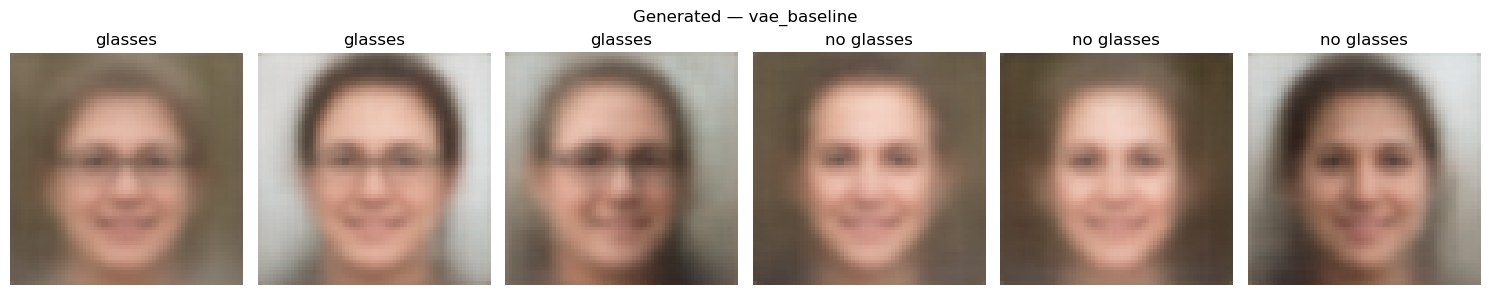

In [73]:

load_and_generate("vae_baseline")


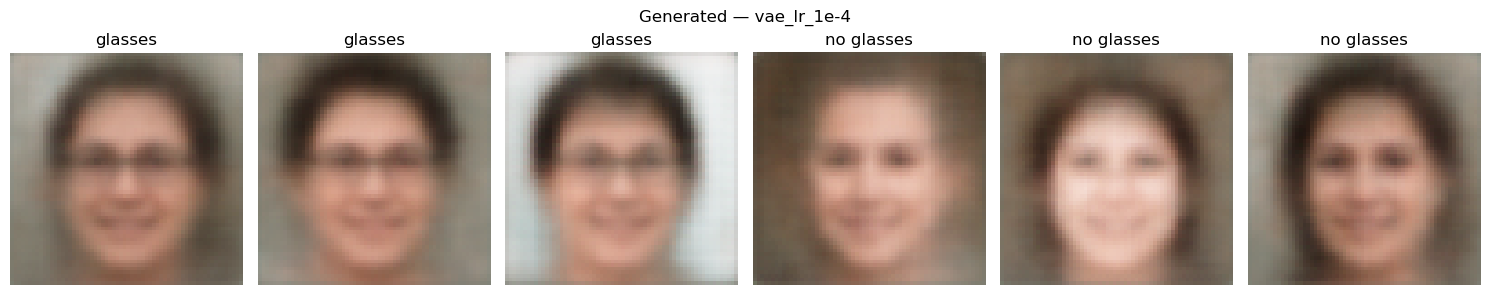

In [74]:

load_and_generate("vae_lr_1e-4")


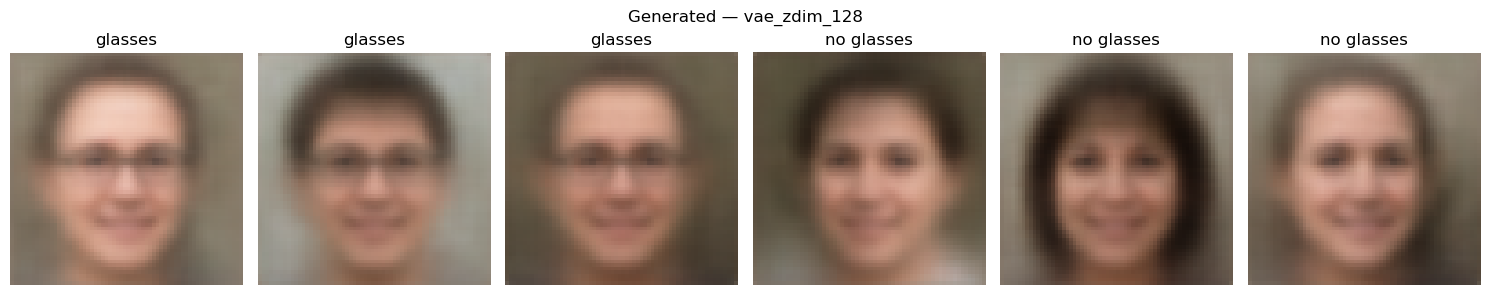

In [75]:

load_and_generate("vae_zdim_128")


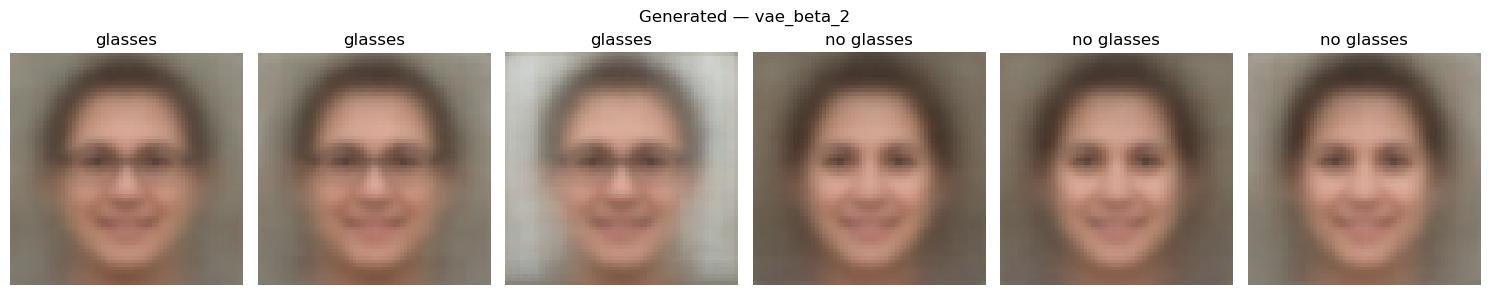

In [76]:

load_and_generate("vae_beta_2")


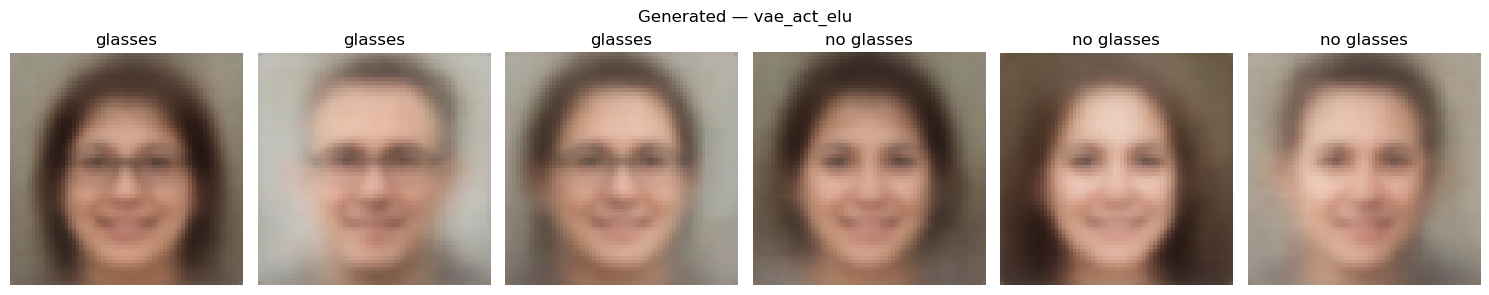

In [77]:

load_and_generate("vae_act_elu")


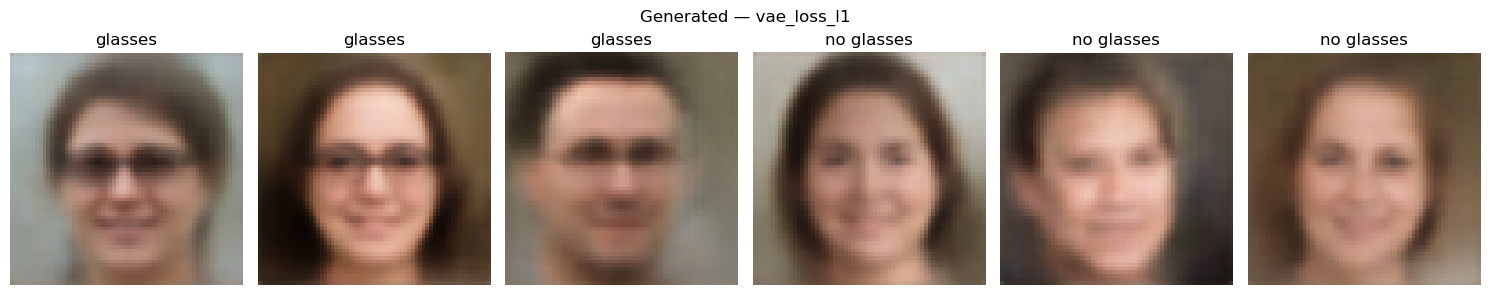

In [ ]:


load_and_generate("vae_loss_l1")